In [1]:
"""
Audio Effects Demonstration - Reverb, Delay, and Distortion

This notebook demonstrates the audio effects with playable audio samples.
You can listen to each effect and adjust parameters interactively.
"""

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, Markdown, display

from src.engine import (
    ADSREnvelope,
    Delay,
    Distortion,
    ModulatedOscillator,
    Reverb,
    SineOscillator,
)

# Audio settings
SAMPLE_RATE = 44100
plt.style.use("default")

print("🎵 Audio Effects Demonstration")
print("=" * 70)
print("Listen to each effect with playable audio controls!")
print()

🎵 Audio Effects Demonstration
Listen to each effect with playable audio controls!



In [2]:
# Helper function to create a musical note with ADSR envelope
def create_note(frequency, duration=1.0, sample_rate=SAMPLE_RATE):
    """Create a musical note with ADSR envelope."""
    n_samples = int(duration * sample_rate)

    # Create ADSR envelope
    env = ADSREnvelope(
        attack_duration=0.01,
        decay_duration=0.1,
        sustain_level=0.7,
        release_duration=0.3,
    )
    env.trigger_note_on()

    # Create oscillator
    osc = SineOscillator(frequency=frequency, gain_db=-12)

    # Modulate with envelope
    mod_osc = ModulatedOscillator(
        osc, env, amp_mod=lambda base_amp, env_val: base_amp * env_val
    )

    # Generate samples (trigger release after 70% of duration)
    samples = mod_osc.get_samples_vectorized(int(n_samples * 0.7))
    mod_osc.trigger_release()
    samples_release = mod_osc.get_samples_vectorized(n_samples - len(samples))

    return np.concatenate([samples, samples_release])


def plot_waveform(samples, title, sample_rate=SAMPLE_RATE, max_samples=4410):
    """Plot waveform for visualization."""
    plot_samples = samples[:max_samples]
    time = np.arange(len(plot_samples)) / sample_rate * 1000  # in ms

    plt.figure(figsize=(12, 3))
    plt.plot(time, plot_samples, linewidth=0.8)
    plt.title(title, fontsize=12, fontweight="bold")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. Distortion Effect
Distortion adds harmonics through non-linear waveshaping. Try different types!


🎸 Distortion Effect Demonstration
----------------------------------------------------------------------


### Original (Clean) Signal

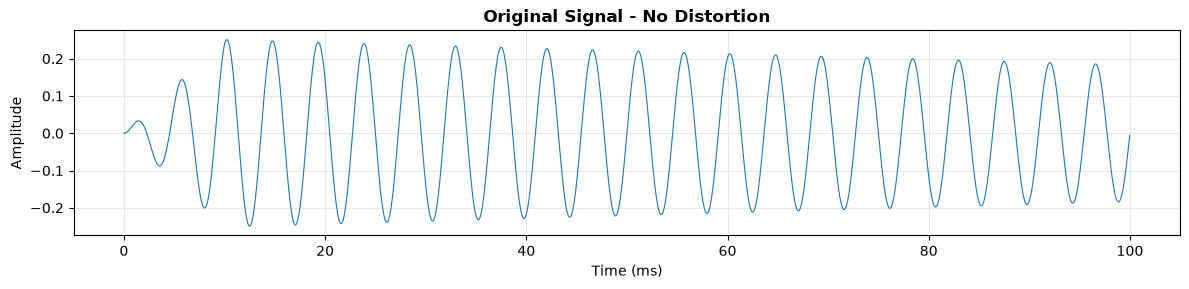

In [3]:
# Create a clean test signal
print("\n🎸 Distortion Effect Demonstration")
print("-" * 70)

# Clean signal (for comparison)
clean_note = create_note(frequency=220, duration=2.0)  # A3

display(Markdown("### Original (Clean) Signal"))
plot_waveform(clean_note, "Original Signal - No Distortion")
display(Audio(clean_note, rate=SAMPLE_RATE))

### Soft Distortion (Warm Overdrive)

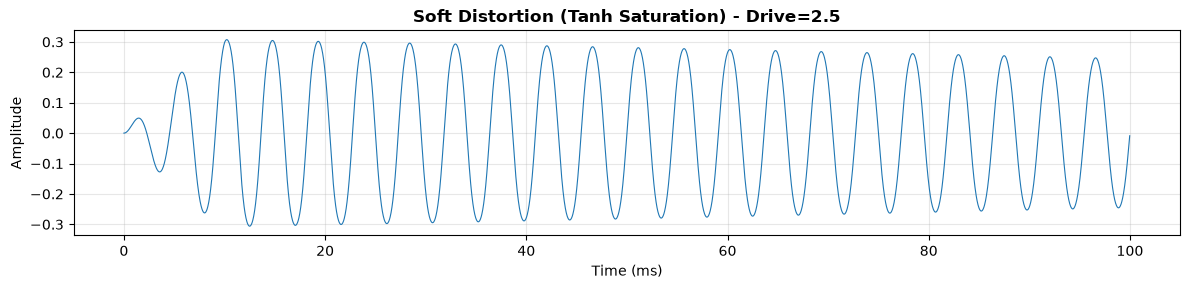

✓ Soft distortion: Smooth, warm analog-style overdrive


In [4]:
osc = SineOscillator(frequency=220, gain_db=-12)
env = ADSREnvelope(
    attack_duration=0.01, decay_duration=0.1, sustain_level=0.7, release_duration=0.3
)
env.trigger_note_on()
mod_osc = ModulatedOscillator(
    osc, env, amp_mod=lambda base_amp, env_val: base_amp * env_val
)

dist_soft = Distortion(
    source=mod_osc, drive=2.5, mix=0.8, output_gain=0.5, distortion_type="soft"
)

samples_soft = dist_soft.get_samples_vectorized(int(1.4 * SAMPLE_RATE))
mod_osc.trigger_release()
samples_soft_release = dist_soft.get_samples_vectorized(int(0.6 * SAMPLE_RATE))
samples_soft = np.concatenate([samples_soft, samples_soft_release])

plot_waveform(samples_soft, "Soft Distortion (Tanh Saturation) - Drive=2.5")
display(Audio(samples_soft, rate=SAMPLE_RATE))
print("✓ Soft distortion: Smooth, warm analog-style overdrive")

### Hard Distortion (Aggressive Clipping)

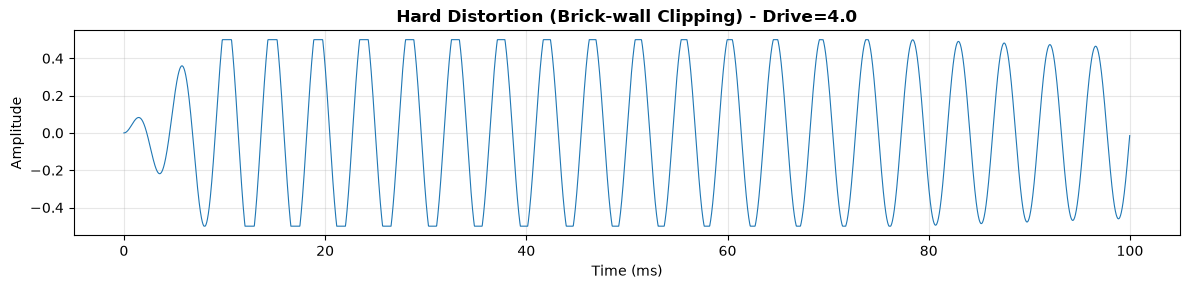

✓ Hard distortion: Aggressive digital-style clipping


In [5]:
osc2 = SineOscillator(frequency=220, gain_db=-12)
env2 = ADSREnvelope(
    attack_duration=0.01, decay_duration=0.1, sustain_level=0.7, release_duration=0.3
)
env2.trigger_note_on()
mod_osc2 = ModulatedOscillator(
    osc2, env2, amp_mod=lambda base_amp, env_val: base_amp * env_val
)

dist_hard = Distortion(
    source=mod_osc2, drive=4.0, mix=1.0, output_gain=0.5, distortion_type="hard"
)

samples_hard = dist_hard.get_samples_vectorized(int(1.4 * SAMPLE_RATE))
mod_osc2.trigger_release()
samples_hard_release = dist_hard.get_samples_vectorized(int(0.6 * SAMPLE_RATE))
samples_hard = np.concatenate([samples_hard, samples_hard_release])

plot_waveform(samples_hard, "Hard Distortion (Brick-wall Clipping) - Drive=4.0")
display(Audio(samples_hard, rate=SAMPLE_RATE))
print("✓ Hard distortion: Aggressive digital-style clipping")

### Fuzz Distortion (Compressed)

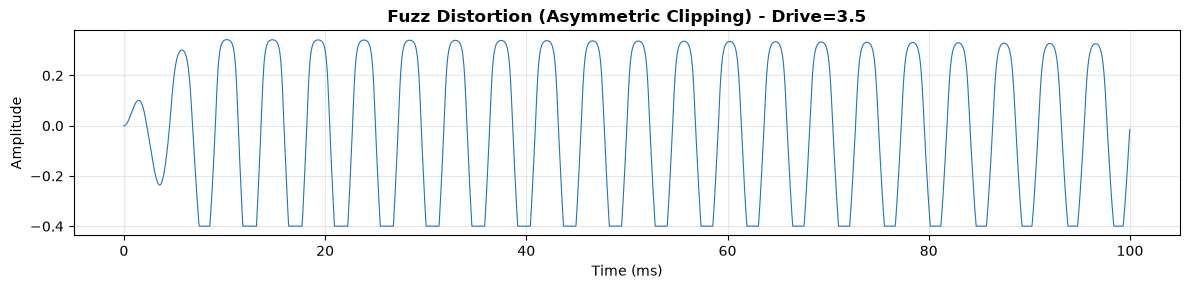

✓ Fuzz distortion: Compressed, asymmetric saturation


In [6]:
osc3 = SineOscillator(frequency=220, gain_db=-12)
env3 = ADSREnvelope(
    attack_duration=0.01, decay_duration=0.1, sustain_level=0.7, release_duration=0.3
)
env3.trigger_note_on()
mod_osc3 = ModulatedOscillator(
    osc3, env3, amp_mod=lambda base_amp, env_val: base_amp * env_val
)

dist_fuzz = Distortion(
    source=mod_osc3, drive=3.5, mix=1.0, output_gain=0.5, distortion_type="fuzz"
)

samples_fuzz = dist_fuzz.get_samples_vectorized(int(1.4 * SAMPLE_RATE))
mod_osc3.trigger_release()
samples_fuzz_release = dist_fuzz.get_samples_vectorized(int(0.6 * SAMPLE_RATE))
samples_fuzz = np.concatenate([samples_fuzz, samples_fuzz_release])

plot_waveform(samples_fuzz, "Fuzz Distortion (Asymmetric Clipping) - Drive=3.5")
display(Audio(samples_fuzz, rate=SAMPLE_RATE))
print("✓ Fuzz distortion: Compressed, asymmetric saturation")

### Tube Distortion (Vintage)

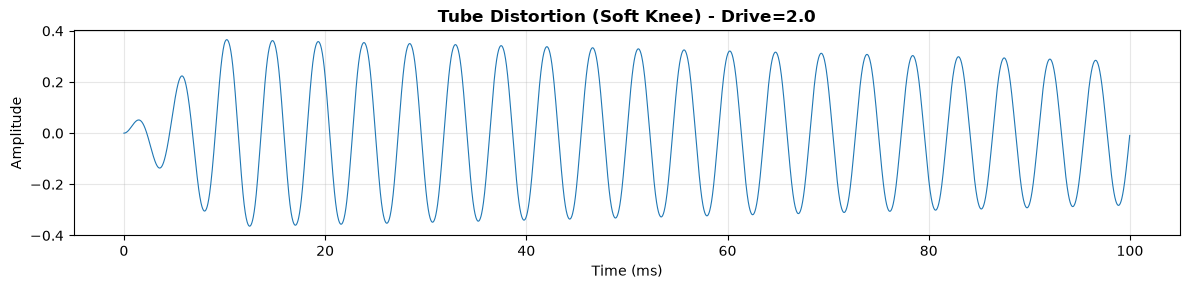

✓ Tube distortion: Vintage tube amplifier emulation


In [7]:
# Tube Distortion
osc4 = SineOscillator(frequency=220, gain_db=-12)
env4 = ADSREnvelope(
    attack_duration=0.01, decay_duration=0.1, sustain_level=0.7, release_duration=0.3
)
env4.trigger_note_on()
mod_osc4 = ModulatedOscillator(
    osc4, env4, amp_mod=lambda base_amp, env_val: base_amp * env_val
)

dist_tube = Distortion(
    source=mod_osc4, drive=2.0, mix=0.8, output_gain=0.6, distortion_type="tube"
)

samples_tube = dist_tube.get_samples_vectorized(int(1.4 * SAMPLE_RATE))
mod_osc4.trigger_release()
samples_tube_release = dist_tube.get_samples_vectorized(int(0.6 * SAMPLE_RATE))
samples_tube = np.concatenate([samples_tube, samples_tube_release])

plot_waveform(samples_tube, "Tube Distortion (Soft Knee) - Drive=2.0")
display(Audio(samples_tube, rate=SAMPLE_RATE))
print("✓ Tube distortion: Vintage tube amplifier emulation")

## 2. Delay Effect
Delay creates echoes by playing back the signal after a time delay with optional feedback.


🔄 Delay Effect Demonstration
----------------------------------------------------------------------


### Original Pattern (No Delay)

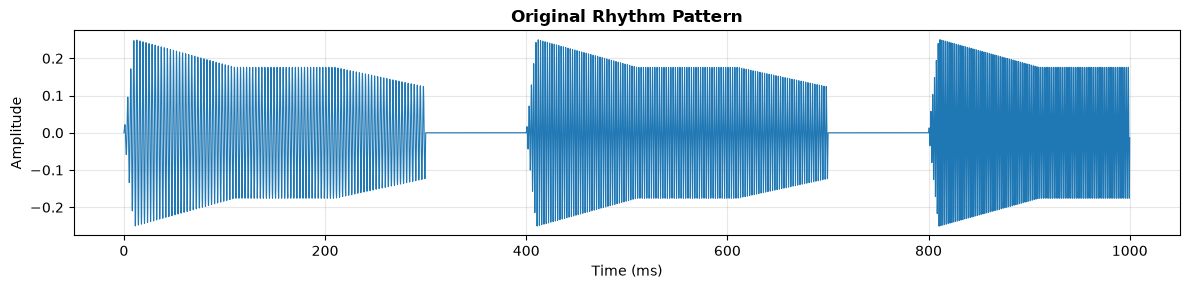

In [8]:
print("\n🔄 Delay Effect Demonstration")
print("-" * 70)


# Short rhythm pattern for delay demo
def create_rhythm_pattern():
    """Create a rhythmic pattern to demonstrate delay."""
    pattern = []
    notes = [330, 440, 550, 440]  # E4, A4, C#5, A4

    for note in notes:
        note_samples = create_note(note, duration=0.3)
        silence = np.zeros(int(0.1 * SAMPLE_RATE))
        pattern.extend(note_samples)
        pattern.extend(silence)

    return np.array(pattern)


# Original pattern
original_pattern = create_rhythm_pattern()

display(Markdown("### Original Pattern (No Delay)"))
plot_waveform(original_pattern, "Original Rhythm Pattern", max_samples=SAMPLE_RATE)
display(Audio(original_pattern, rate=SAMPLE_RATE))

### Short Delay (Slapback Echo)

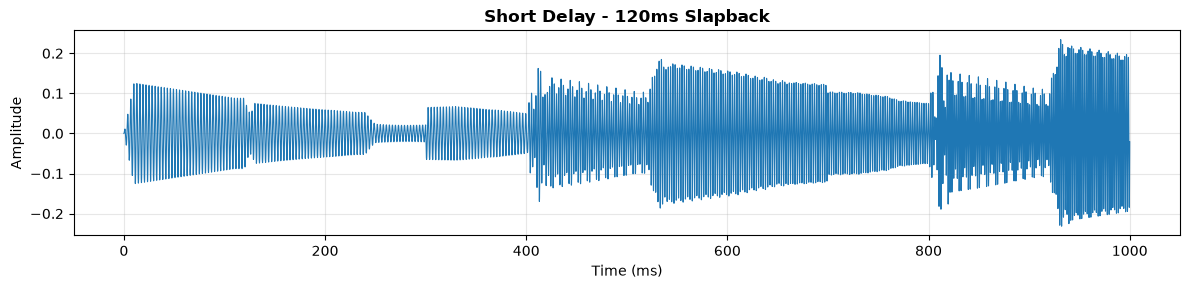

✓ Short delay (120ms): Classic slapback echo effect


In [9]:
# Short delay (slapback)
display(Markdown("### Short Delay (Slapback Echo)"))


class PatternSource:
    """Wrapper to use pre-generated pattern as source."""

    def __init__(self, samples):
        self.samples = samples
        self.pos = 0

    def get_samples_vectorized(self, n):
        end_pos = min(self.pos + n, len(self.samples))
        result = self.samples[self.pos : end_pos]
        self.pos = end_pos
        if len(result) < n:
            result = np.concatenate([result, np.zeros(n - len(result))])
        return result


pattern_source1 = PatternSource(create_rhythm_pattern())
delay_short = Delay(
    source=pattern_source1,
    delay_time=0.12,  # 120ms - slapback
    feedback=0.3,
    mix=0.5,
    sample_rate=SAMPLE_RATE,
)

samples_delay_short = delay_short.get_samples_vectorized(len(original_pattern))
plot_waveform(
    samples_delay_short, "Short Delay - 120ms Slapback", max_samples=SAMPLE_RATE
)
display(Audio(samples_delay_short, rate=SAMPLE_RATE))
print("✓ Short delay (120ms): Classic slapback echo effect")

### Medium Delay (Rhythmic Echo)

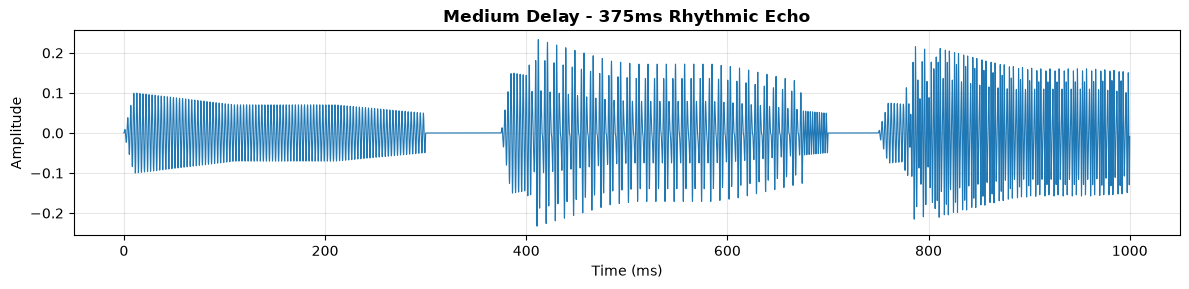

✓ Medium delay (375ms): Rhythmic echo with feedback


In [10]:
# Medium delay with feedback
display(Markdown("### Medium Delay (Rhythmic Echo)"))
pattern_source2 = PatternSource(create_rhythm_pattern())
delay_medium = Delay(
    source=pattern_source2,
    delay_time=0.375,  # ~375ms - quarter note at 160 BPM
    feedback=0.5,
    mix=0.6,
    sample_rate=SAMPLE_RATE,
)

samples_delay_medium = delay_medium.get_samples_vectorized(
    len(original_pattern) + SAMPLE_RATE
)
plot_waveform(
    samples_delay_medium, "Medium Delay - 375ms Rhythmic Echo", max_samples=SAMPLE_RATE
)
display(Audio(samples_delay_medium, rate=SAMPLE_RATE))
print("✓ Medium delay (375ms): Rhythmic echo with feedback")

### Long Delay (Ambient Repeats)

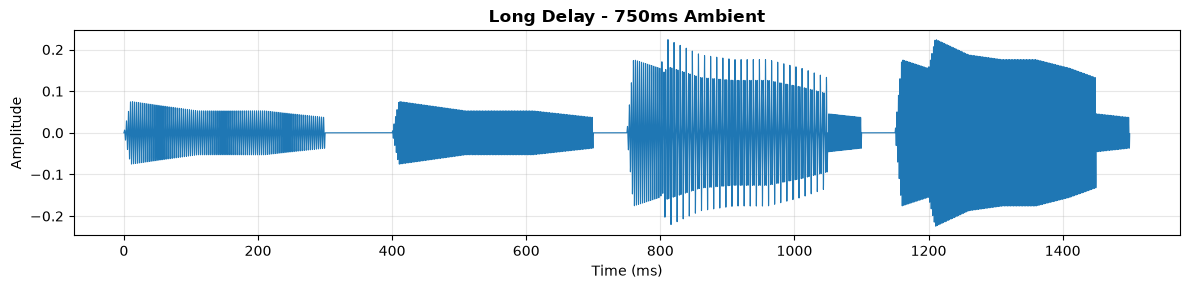

✓ Long delay (750ms): Ambient, spacious repeats


In [11]:
# Long delay with high feedback
display(Markdown("### Long Delay (Ambient Repeats)"))
pattern_source3 = PatternSource(create_rhythm_pattern())
delay_long = Delay(
    source=pattern_source3,
    delay_time=0.75,  # 750ms
    feedback=0.6,
    mix=0.7,
    sample_rate=SAMPLE_RATE,
)

samples_delay_long = delay_long.get_samples_vectorized(
    len(original_pattern) + int(2 * SAMPLE_RATE)
)
plot_waveform(
    samples_delay_long, "Long Delay - 750ms Ambient", max_samples=int(1.5 * SAMPLE_RATE)
)
display(Audio(samples_delay_long, rate=SAMPLE_RATE))
print("✓ Long delay (750ms): Ambient, spacious repeats")

## 3. Reverb Effect
Reverb simulates the natural reflections of sound in a physical space.


🏛️ Reverb Effect Demonstration
----------------------------------------------------------------------


### Original Chord (Dry)

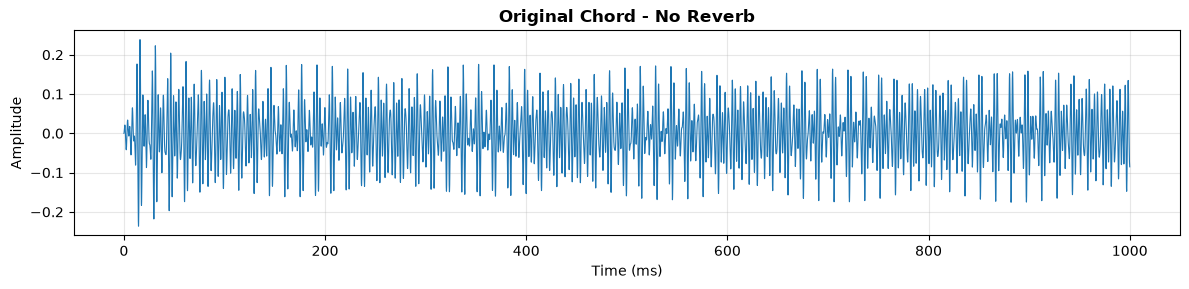

In [12]:
print("\n🏛️ Reverb Effect Demonstration")
print("-" * 70)


# Create a chord for reverb demo
def create_chord(duration=1.5):
    """Create a chord to demonstrate reverb."""
    frequencies = [261.63, 329.63, 392.00]  # C4, E4, G4 (C major chord)
    chord_samples = np.zeros(int(duration * SAMPLE_RATE))

    for freq in frequencies:
        note = create_note(freq, duration=duration)
        chord_samples[: len(note)] += note / len(frequencies)

    return chord_samples


original_chord = create_chord()

display(Markdown("### Original Chord (Dry)"))
plot_waveform(original_chord, "Original Chord - No Reverb", max_samples=SAMPLE_RATE)
display(Audio(original_chord, rate=SAMPLE_RATE))

### Small Room Reverb

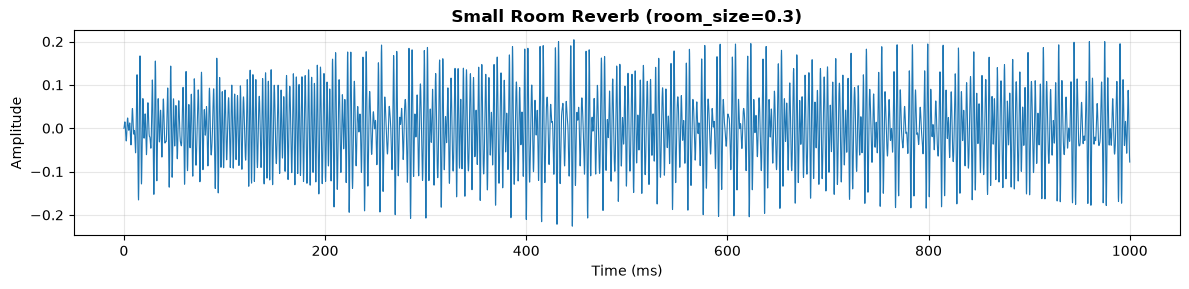

✓ Small room: Tight, controlled reverb


In [13]:
chord_source1 = PatternSource(create_chord())
reverb_small = Reverb(
    source=chord_source1, room_size=0.3, damping=0.3, mix=0.3, sample_rate=SAMPLE_RATE
)

samples_reverb_small = reverb_small.get_samples_vectorized(int(2.5 * SAMPLE_RATE))
plot_waveform(
    samples_reverb_small, "Small Room Reverb (room_size=0.3)", max_samples=SAMPLE_RATE
)
display(Audio(samples_reverb_small, rate=SAMPLE_RATE))
print("✓ Small room: Tight, controlled reverb")

### Medium Hall Reverb

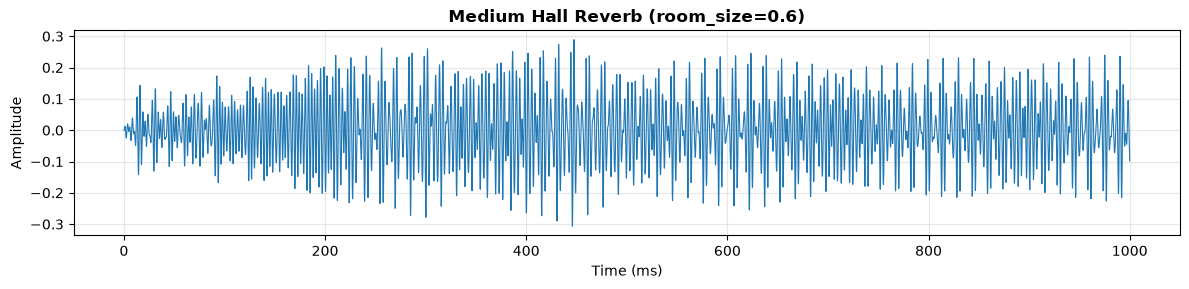

✓ Medium hall: Natural, balanced reverb


In [14]:
chord_source2 = PatternSource(create_chord())
reverb_medium = Reverb(
    source=chord_source2, room_size=0.6, damping=0.5, mix=0.4, sample_rate=SAMPLE_RATE
)

samples_reverb_medium = reverb_medium.get_samples_vectorized(int(3.0 * SAMPLE_RATE))
plot_waveform(
    samples_reverb_medium, "Medium Hall Reverb (room_size=0.6)", max_samples=SAMPLE_RATE
)
display(Audio(samples_reverb_medium, rate=SAMPLE_RATE))
print("✓ Medium hall: Natural, balanced reverb")

### Large Cathedral Rever

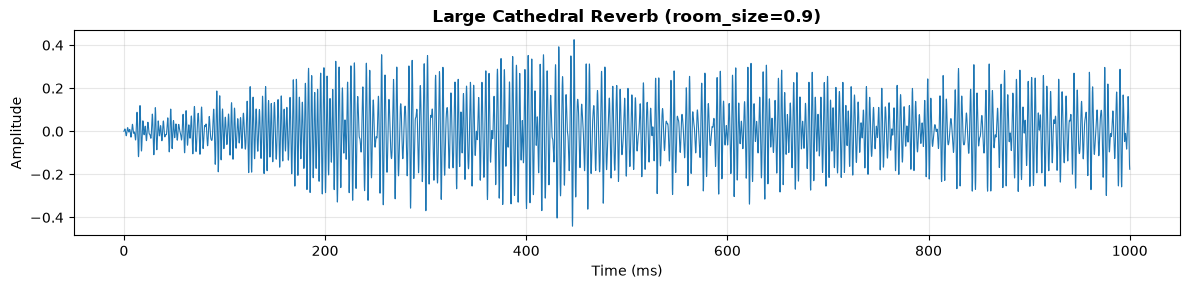

✓ Large cathedral: Spacious, long decay


In [15]:
# Large cathedral reverb
chord_source3 = PatternSource(create_chord())
reverb_large = Reverb(
    source=chord_source3, room_size=0.9, damping=0.6, mix=0.5, sample_rate=SAMPLE_RATE
)

samples_reverb_large = reverb_large.get_samples_vectorized(int(4.0 * SAMPLE_RATE))
plot_waveform(
    samples_reverb_large,
    "Large Cathedral Reverb (room_size=0.9)",
    max_samples=SAMPLE_RATE,
)
display(Audio(samples_reverb_large, rate=SAMPLE_RATE))
print("✓ Large cathedral: Spacious, long decay")

### Bright Reverb (Low Damping)

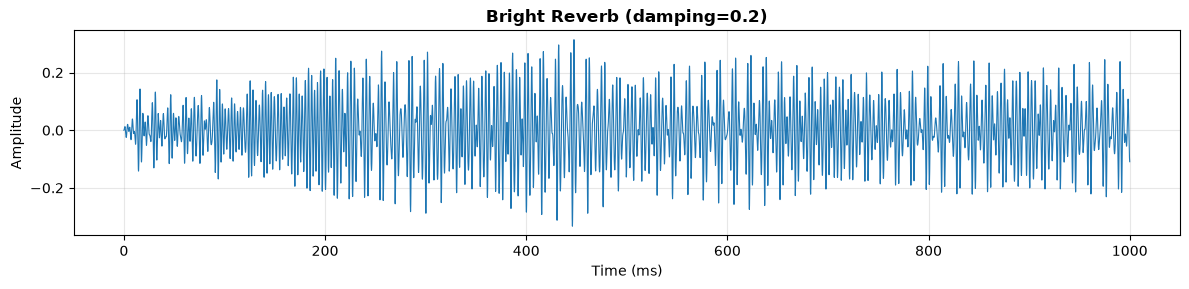

✓ Bright reverb: Shimmering, airy quality


In [16]:
chord_source4 = PatternSource(create_chord())
reverb_bright = Reverb(
    source=chord_source4,
    room_size=0.7,
    damping=0.2,  # Low damping = bright
    mix=0.4,
    sample_rate=SAMPLE_RATE,
)

samples_reverb_bright = reverb_bright.get_samples_vectorized(int(3.0 * SAMPLE_RATE))
plot_waveform(
    samples_reverb_bright, "Bright Reverb (damping=0.2)", max_samples=SAMPLE_RATE
)
display(Audio(samples_reverb_bright, rate=SAMPLE_RATE))
print("✓ Bright reverb: Shimmering, airy quality")

### Dark Reverb (High Damping)

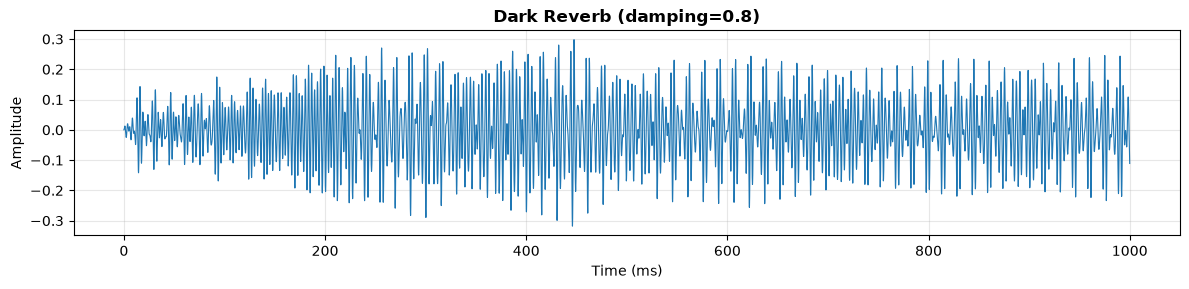

✓ Dark reverb: Warm, mellow quality


In [17]:
chord_source5 = PatternSource(create_chord())
reverb_dark = Reverb(
    source=chord_source5,
    room_size=0.7,
    damping=0.8,  # High damping = dark
    mix=0.4,
    sample_rate=SAMPLE_RATE,
)

samples_reverb_dark = reverb_dark.get_samples_vectorized(int(3.0 * SAMPLE_RATE))
plot_waveform(samples_reverb_dark, "Dark Reverb (damping=0.8)", max_samples=SAMPLE_RATE)
display(Audio(samples_reverb_dark, rate=SAMPLE_RATE))
print("✓ Dark reverb: Warm, mellow quality")

## 4. Combined Effects Chain
Let's combine all three effects for a complete production sound!


🎛️ Combined Effects Chain
----------------------------------------------------------------------


### Original Melody (Dry)

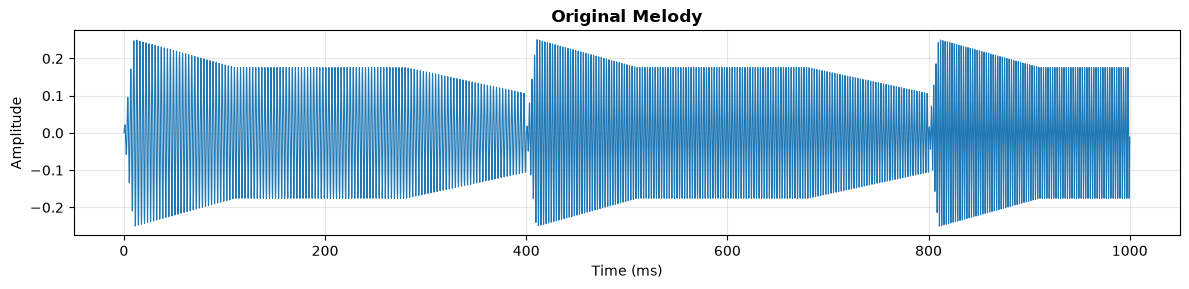

In [18]:
print("\n🎛️ Combined Effects Chain")
print("-" * 70)


# Create a melody
def create_melody():
    """Create a simple melody."""
    melody_notes = [
        (330, 0.4),  # E4
        (392, 0.4),  # G4
        (440, 0.4),  # A4
        (523, 0.8),  # C5
        (440, 0.4),  # A4
        (392, 0.4),  # G4
        (330, 0.8),  # E4
    ]

    melody = []
    for freq, dur in melody_notes:
        note = create_note(freq, duration=dur)
        melody.extend(note)

    return np.array(melody)


original_melody = create_melody()

display(Markdown("### Original Melody (Dry)"))
plot_waveform(original_melody, "Original Melody", max_samples=SAMPLE_RATE)
display(Audio(original_melody, rate=SAMPLE_RATE))

### With All Effects: Distortion → Delay → Reverb

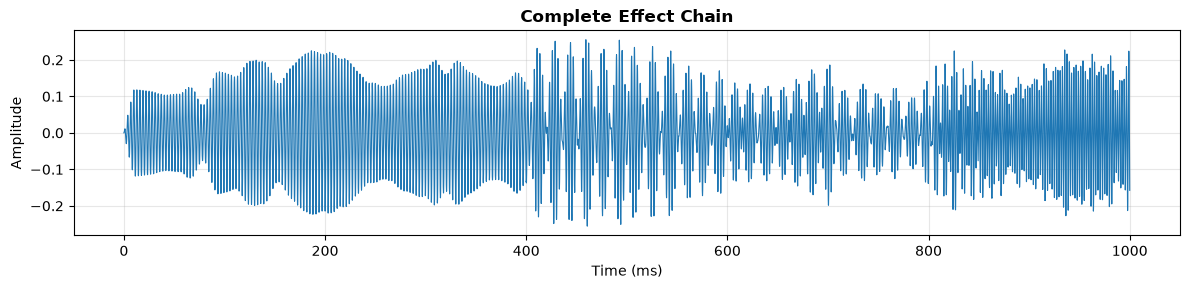

✓ Complete chain: Professional, polished sound


In [19]:
melody_source = PatternSource(create_melody())

# Chain effects together
dist = Distortion(
    source=melody_source, drive=1.5, mix=0.4, output_gain=0.7, distortion_type="soft"
)

delay = Delay(
    source=dist, delay_time=0.3, feedback=0.35, mix=0.35, sample_rate=SAMPLE_RATE
)

reverb = Reverb(
    source=delay, room_size=0.6, damping=0.5, mix=0.3, sample_rate=SAMPLE_RATE
)

samples_combined = reverb.get_samples_vectorized(
    len(original_melody) + int(2 * SAMPLE_RATE)
)
plot_waveform(samples_combined, "Complete Effect Chain", max_samples=SAMPLE_RATE)
display(Audio(samples_combined, rate=SAMPLE_RATE))
print("✓ Complete chain: Professional, polished sound")

## Summary

### Effect Parameters Quick Reference

**Distortion:**
- `drive`: 0.0-10.0 (distortion amount)
- `mix`: 0.0-1.0 (dry/wet blend)
- `output_gain`: 0.0-2.0 (level compensation)
- `distortion_type`: 'soft', 'hard', 'fuzz', 'tube'

**Delay:**
- `delay_time`: 0.001-2.0 seconds
- `feedback`: 0.0-0.95 (echo repeats)
- `mix`: 0.0-1.0 (dry/wet blend)

**Reverb:**
- `room_size`: 0.0-1.0 (space size)
- `damping`: 0.0-1.0 (high frequency absorption)
- `mix`: 0.0-1.0 (dry/wet blend)

### Tips for Best Results:
1. **Distortion**: Use before delay/reverb, keep drive under 5.0 for musical results
2. **Delay**: Feedback below 0.95 to avoid runaway, sync to tempo for rhythm
3. **Reverb**: Lower damping = brighter, higher = warmer, keep mix 20-40% for natural sound
4. **Chaining**: Standard order is Distortion → Delay → Reverb

In [20]:
print("\n" + "=" * 70)
print("✓ Effects demonstration complete!")
print("=" * 70)


✓ Effects demonstration complete!
